# Import Modules

In [1]:
from utils import *
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False

# Validation

In [2]:
issues_df = run_validation(load_ocr_data)

Issues: 589 row(s)
 - District Issues: 129
 - Partylist Issues: 205
 - Referendum Issues: 255


In [3]:
issues_df = run_validation(load_ocr_clean_data)

Issues: 3 row(s)
 - District Issues: 2
 - Partylist Issues: 1
 - Referendum Issues: 0


# Clean Data

In [4]:
dfs_district = []
dfs_partylist = []
dfs_referendum = []

for file_config in OCR_FILES:
    total_pages = file_config["pages"]
    if "district" in file_config["path"]: 
        for page_num in range(1, total_pages, 2):
            df_dict = load_ocr_clean_data(file_config["path"], page_num)
            dfs_district.append(df_dict)
            
    elif "partylist" in file_config["path"]:
        for page_num in range(1, total_pages, 4):
            df_dict = load_ocr_clean_data(file_config["path"], page_num)
            dfs_partylist.append(df_dict)
            
    elif "referendum" in file_config["path"]:
        for page_num in range(1, total_pages, 2):
            df_dict = load_ocr_clean_data(file_config["path"], page_num)
            dfs_referendum.append(df_dict)

In [5]:
print(f"Total District Units: {len(dfs_district)}")
print(f"Total Partylist Units: {len(dfs_partylist)}")
print(f"Total Referendum Units: {len(dfs_referendum)}")

Total District Units: 279
Total Partylist Units: 279
Total Referendum Units: 272


In [6]:
district_summary, district_scores = flatten_district(
    dfs_district
)
partylist_summary, partylist_scores = flatten_partylist(
    dfs_partylist
)
referendum_summary, referendum_scores = flatten_referendum(
    dfs_referendum
)

district_scores["คะแนน"] = pd.to_numeric(district_scores["คะแนน"], errors="coerce").fillna(0).astype(int)
partylist_scores["คะแนน"] = pd.to_numeric(partylist_scores["คะแนน"], errors="coerce").fillna(0).astype(int)
referendum_scores["คะแนน"] = pd.to_numeric(referendum_scores["คะแนน"], errors="coerce").fillna(0).astype(int)

In [7]:
district_summary.tail(5)

,unit_key,อำเภอ,ตำบล,หน่วย,จำนวนบัตรทั้งหมด,บัตรดี,บัตรเสีย,ไม่เลือกผู้ใด
274,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,18,480,274,17,3
275,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,19,200,131,4,3
276,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,20,420,237,10,9
277,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,21,440,287,15,11
278,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,400,212,15,9


In [8]:
district_scores.tail(10)

,unit_key,อำเภอ,ตำบล,หน่วย,ชื่อผู้สมัคร,พรรค,คะแนน
2222,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,21,นายนาท ฉัพพรรณธนกูร,กล้าธรรม,1
2223,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,21,นายอิทธิพัทธ์ ภักดีเนติพันธุ์,เศรษฐกิจ,6
2224,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,นายภาคภูมิ โภคทรัพย์,ประชาธิปัตย์,2
2225,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,นายพีรภัทร ทองธีรสกุล,เพื่อไทย,13
2226,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,นายธนายุทธ ยืนยั่ง,ประชาชน,45
2227,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,นางสุทธิลักษณ์ ยายิรัมย์,รวมไทยสร้างชาติ,2
2228,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,นายสนอง เทพอักษรณรงค์,ภูมิใจไทย,145
2229,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,นายวิเชียร ลานทอง,ประชากรไทย,1
2230,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,นายนาท ฉัพพรรณธนกูร,กล้าธรรม,3
2231,district/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองตา...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,นายอิทธิพัทธ์ ภักดีเนติพันธุ์,เศรษฐกิจ,1


In [9]:
partylist_summary.tail(5)

,unit_key,อำเภอ,ตำบล,หน่วย,จำนวนบัตรทั้งหมด,บัตรดี,บัตรเสีย,ไม่เลือกผู้ใด
274,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,18,480,269,23,4
275,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,19,200,125,13,0
276,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,20,420,248,7,1
277,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,21,440,295,11,1
278,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,400,208,18,10


In [10]:
partylist_scores.tail(10)

,unit_key,อำเภอ,ตำบล,หน่วย,พรรค,คะแนน
15893,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,ไทยสร้างไทย,2
15894,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,ไทยก้าวใหม่,1
15895,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,ประชาอาสาชาติ,0
15896,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,พร้อม,0
15897,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,เครือข่ายชาวนาแห่งประเทศไทย,0
15898,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,ไทยพิทักษ์ธรรม,0
15899,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,ความหวังใหม่,0
15900,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,ไทยรวมไทย,0
15901,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,เพื่อบ้านเมือง,0
15902,partylist/ontime/อำเภอเมืองบุรีรัมย์/ตำบลหนองต...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,พลังไทยรักชาติ,0


In [11]:
referendum_summary.tail(5)

,unit_key,อำเภอ,ตำบล,หน่วย,ผู้มีสิทธิ,ผู้มาใช้สิทธิ,บัตรเสีย
267,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,18,486,296,11
268,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,19,213,138,6
269,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,20,425,256,6
270,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,21,459,313,11
271,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,401,236,9


In [12]:
referendum_scores.tail(5)

,unit_key,อำเภอ,ตำบล,หน่วย,รายการ,คะแนน
811,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,21,ไม่เห็นชอบ,86
812,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,21,ไม่แสดงความคิดเห็น,39
813,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,เห็นชอบ,124
814,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,ไม่เห็นชอบ,80
815,referendum/inside/อำเภอเมืองบุรีรัมย์/ตำบลหนอง...,อำเภอเมืองบุรีรัมย์,ตำบลหนองตาด,22,ไม่แสดงความคิดเห็น,23


In [13]:
district_summary.to_csv("flatten_result/district_summary.csv")
district_scores.to_csv("flatten_result/district_scores.csv")
partylist_summary.to_csv("flatten_result/partylist_summary.csv")
partylist_scores.to_csv("flatten_result/partylist_scores.csv")
referendum_summary.to_csv("flatten_result/referendum_summary.csv")
referendum_scores.to_csv("flatten_result/referendum_scores.csv")

# Insights

## สส.เขต

### 1. คะแนนรวมแต่ละผู้สมัคร

,ชื่อผู้สมัคร,พรรค,คะแนน,% คะแนน
1,นายสนอง เทพอักษรณรงค์,ภูมิใจไทย,56898,72.12
2,นายธนายุทธ ยืนยั่ง,ประชาชน,14693,18.62
3,นายพีรภัทร ทองธีรสกุล,เพื่อไทย,3447,4.37
4,นายภาคภูมิ โภคทรัพย์,ประชาธิปัตย์,1366,1.73
5,นายอิทธิพัทธ์ ภักดีเนติพันธุ์,เศรษฐกิจ,749,0.95
6,นางสุทธิลักษณ์ ยายิรัมย์,รวมไทยสร้างชาติ,740,0.94
7,นายวิเชียร ลานทอง,ประชากรไทย,505,0.64
8,นายนาท ฉัพพรรณธนกูร,กล้าธรรม,491,0.62


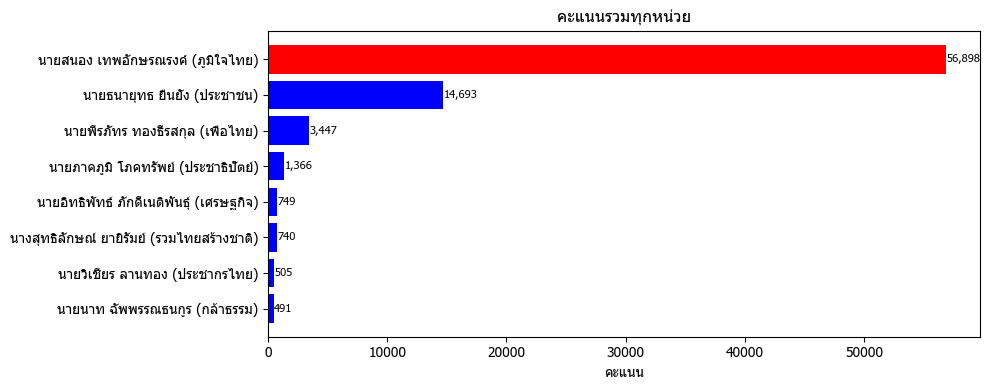

In [14]:
d1 = (district_scores.groupby(["ชื่อผู้สมัคร", "พรรค"], as_index=False)["คะแนน"]
        .sum().sort_values("คะแนน", ascending=False).reset_index(drop=True))
d1.index += 1
d1["% คะแนน"] = (d1["คะแนน"] / d1["คะแนน"].sum() * 100).round(2)

display(d1)

fig, ax = plt.subplots(figsize=(10, max(4, len(d1) * 0.5)))
colors = ["red" if i == 0 else "blue" for i in range(len(d1))]
ax.barh(d1["ชื่อผู้สมัคร"] + " (" + d1["พรรค"] + ")", d1["คะแนน"], color=colors)
ax.set_xlabel("คะแนน")
ax.set_title("คะแนนรวมทุกหน่วย")
ax.invert_yaxis()
for i, v in enumerate(d1["คะแนน"]):
    ax.text(v + 10, i, f"{v:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

### 2. จำนวนหน่วยที่ผู้สมัครแต่ละคนชนะ

,ชื่อผู้สมัคร,พรรค,หน่วยที่ชนะ,% หน่วยที่ชนะ
1,นายสนอง เทพอักษรณรงค์,ภูมิใจไทย,270,96.77
2,นายธนายุทธ ยืนยั่ง,ประชาชน,8,2.87
3,นายภาคภูมิ โภคทรัพย์,ประชาธิปัตย์,1,0.36


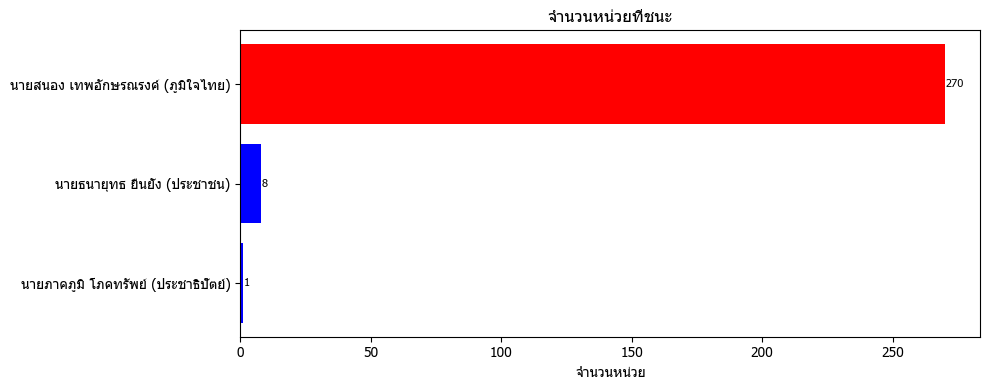

In [15]:
unit_winner = district_scores.loc[
    district_scores.groupby("unit_key")["คะแนน"].idxmax(), ["unit_key", "ชื่อผู้สมัคร", "พรรค"]
]
d2 = (unit_winner.groupby(["ชื่อผู้สมัคร", "พรรค"])
      .size().reset_index(name="หน่วยที่ชนะ")
      .sort_values("หน่วยที่ชนะ", ascending=False).reset_index(drop=True))
d2.index += 1
d2["% หน่วยที่ชนะ"] = (d2["หน่วยที่ชนะ"] / d2["หน่วยที่ชนะ"].sum() * 100).round(2)

display(d2)

fig, ax = plt.subplots(figsize=(10, max(4, len(d2) * 0.5)))
colors = ["red" if i == 0 else "blue" for i in range(len(d2))]
ax.barh(d2["ชื่อผู้สมัคร"] + " (" + d2["พรรค"] + ")", d2["หน่วยที่ชนะ"], color=colors)
ax.set_xlabel("จำนวนหน่วย")
ax.set_title("จำนวนหน่วยที่ชนะ")
ax.invert_yaxis()
for i, v in enumerate(d2["หน่วยที่ชนะ"]):
    ax.text(v + 0.3, i, str(v), va="center", fontsize=8)
plt.tight_layout()
plt.show()

### 3. สัดส่วนการใช้สิทธิเลือกตั้งสส.เขตรายตำบล

C:\Users\USER\AppData\Local\Temp\ipykernel_8084\213350116.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  district_summary.groupby("ตำบล").apply(lambda x: pd.Series({


,ตำบล,บัตรทั้งหมด,บัตรที่ถูกใช้,จำนวนหน่วยเลือกตั้ง,บัตรที่ใช้ต่อหน่วย,บัตรที่เหลือ,% บัตรที่ถูกใช้
14,นอกเขต,6441,5705,8,713.125000,736,88.57
6,ตำบลบ้านบัว,8260,6211,19,326.894737,2049,75.19
2,ตำบลชุมเห็ด,15960,11344,32,354.500000,4616,71.08
0,ตำบลกระสัง,5990,4247,14,303.357143,1743,70.90
13,ตำบลในเมือง,16470,11383,31,367.193548,5087,69.11
7,ตำบลบ้านยาง,11160,7478,22,339.909091,3682,67.01
5,ตำบลบ้านด่าน,9240,6038,20,301.900000,3202,65.35
12,ตำบลหนองตาด,9160,5942,22,270.090909,3218,64.87
4,ตำบลบัวทอง,5243,3378,14,241.285714,1865,64.43
10,ตำบลลุมปุ๊ก,6680,4281,19,225.315789,2399,64.09


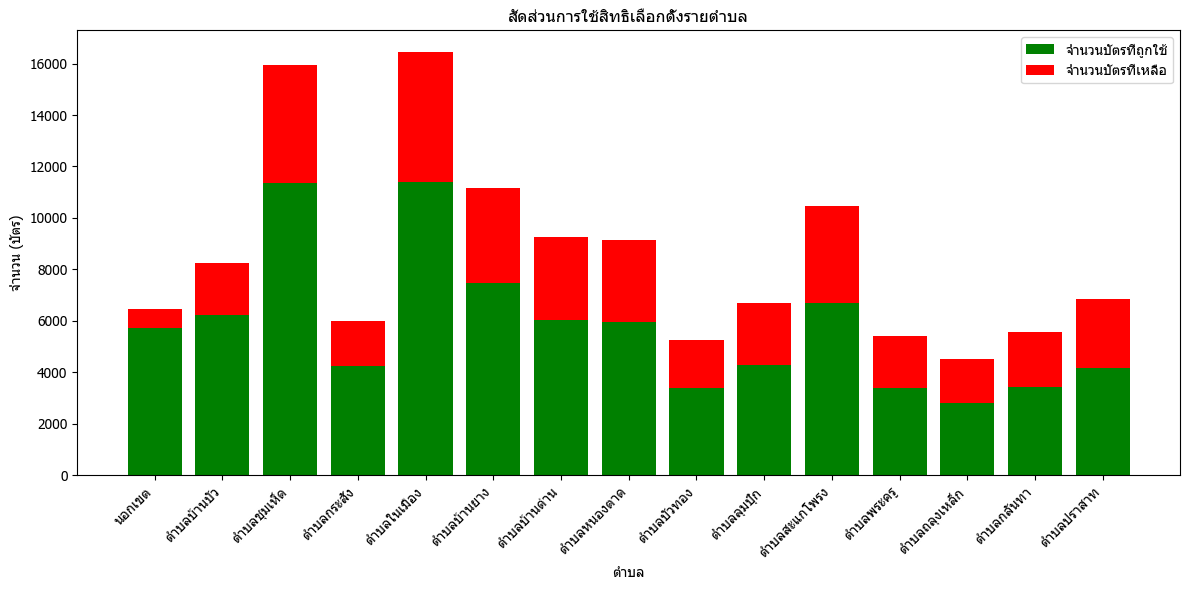

In [16]:
turnout_by_tambon = (
    district_summary.groupby("ตำบล").apply(lambda x: pd.Series({
        "บัตรทั้งหมด": x["จำนวนบัตรทั้งหมด"].sum(),
        "บัตรที่ถูกใช้": (x["บัตรดี"] + x["บัตรเสีย"] + x["ไม่เลือกผู้ใด"]).sum(),
        "จำนวนหน่วยเลือกตั้ง": x["จำนวนบัตรทั้งหมด"].count(),
    }))
).reset_index()
turnout_by_tambon["บัตรที่ใช้ต่อหน่วย"] = turnout_by_tambon["บัตรที่ถูกใช้"] / turnout_by_tambon["จำนวนหน่วยเลือกตั้ง"]
turnout_by_tambon["บัตรที่เหลือ"] = turnout_by_tambon["บัตรทั้งหมด"] - turnout_by_tambon["บัตรที่ถูกใช้"]
turnout_by_tambon["% บัตรที่ถูกใช้"] = (turnout_by_tambon["บัตรที่ถูกใช้"] / turnout_by_tambon["บัตรทั้งหมด"] * 100).round(2)
turnout_by_tambon = turnout_by_tambon.sort_values("% บัตรที่ถูกใช้", ascending=False)

display(turnout_by_tambon)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(turnout_by_tambon["ตำบล"],
       turnout_by_tambon["บัตรที่ถูกใช้"],
       color="green",
       label="จำนวนบัตรที่ถูกใช้")
ax.bar(turnout_by_tambon["ตำบล"],
       turnout_by_tambon["บัตรที่เหลือ"],
       bottom=turnout_by_tambon["บัตรที่ถูกใช้"],
       color="red",
       label="จำนวนบัตรที่เหลือ")
ax.set_xlabel("ตำบล")
ax.set_ylabel("จำนวน (บัตร)")
ax.set_title("สัดส่วนการใช้สิทธิเลือกตั้งรายตำบล")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 4. การกระจายคะแนนแต่ละพรรครายตำบล

พรรค,กล้าธรรม,ประชากรไทย,ประชาชน,ประชาธิปัตย์,ภูมิใจไทย,รวมไทยสร้างชาติ,เพื่อไทย,เศรษฐกิจ
ตำบล,,,,,,,,
ตำบลกระสัง,28.0,25.0,552.0,35.0,3024.0,34.0,158.0,27.0
ตำบลกลันทา,18.0,15.0,440.0,23.0,2529.0,19.0,109.0,17.0
ตำบลชุมเห็ด,63.0,65.0,1974.0,192.0,7139.0,108.0,310.0,126.0
ตำบลถลุงเหล็ก,7.0,15.0,281.0,18.0,2202.0,14.0,106.0,17.0
ตำบลบัวทอง,17.0,23.0,406.0,37.0,2480.0,20.0,140.0,33.0
ตำบลบ้านด่าน,65.0,21.0,832.0,35.0,4217.0,51.0,291.0,58.0
ตำบลบ้านบัว,35.0,30.0,804.0,66.0,4505.0,47.0,180.0,37.0
ตำบลบ้านยาง,33.0,44.0,1285.0,87.0,5089.0,49.0,263.0,58.0
ตำบลปราสาท,28.0,17.0,537.0,30.0,2918.0,33.0,239.0,24.0


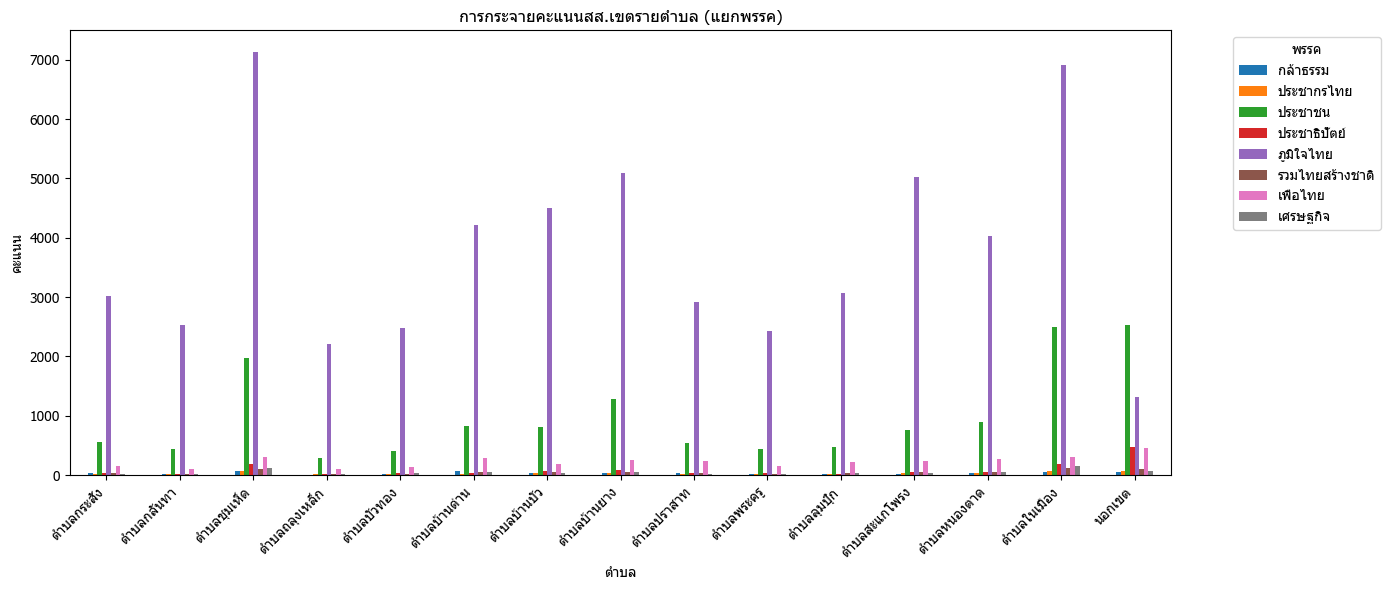

In [17]:
d4 = district_scores.groupby(["ตำบล", "พรรค"], as_index=False)["คะแนน"].sum()
d4_pivot = d4.pivot_table(index="ตำบล", columns="พรรค", values="คะแนน", fill_value=0)
d4_pivot.plot(kind="bar", figsize=(14, 6), title="การกระจายคะแนนสส.เขตรายตำบล (แยกพรรค)")

display(d4_pivot)

plt.ylabel("คะแนน")
plt.xlabel("ตำบล")
plt.xticks(rotation=45, ha="right")
plt.legend(title="พรรค", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

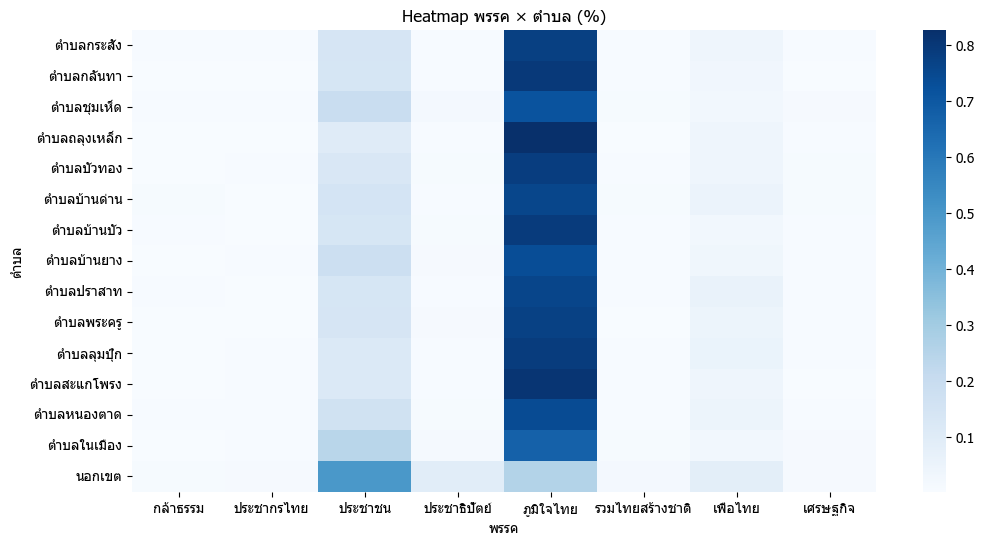

In [18]:
pivot_const = district_scores.pivot_table(index="ตำบล", columns="พรรค", values="คะแนน",
                                          aggfunc="sum", fill_value=0)

pivot_const_pct = pivot_const.div(pivot_const.sum(axis=1), axis=0)

top_const = pivot_const_pct.sum().index
pivot_const_pct = pivot_const_pct[top_const]

plt.figure(figsize=(12,6))
sns.heatmap(pivot_const_pct, cmap="Blues")
plt.title("Heatmap พรรค × ตำบล (%)")
plt.show()

### 5. บัตรเสียรายตำบล

In [19]:
tambon_bad = (district_summary.groupby(["ตำบล", "อำเภอ"])
              .agg({"บัตรเสีย": "sum", "จำนวนบัตรทั้งหมด": "sum"}).reset_index())

tambon_bad["bad_ballot_pct"] = (tambon_bad["บัตรเสีย"] / tambon_bad["จำนวนบัตรทั้งหมด"]).replace([np.inf, -np.inf], np.nan)

total_bad = tambon_bad["บัตรเสีย"].sum()
tambon_bad["bad_ballot_share"] = tambon_bad["บัตรเสีย"] / total_bad
tambon_bad = tambon_bad.sort_values("บัตรเสีย", ascending=False)
display(tambon_bad)

,ตำบล,อำเภอ,บัตรเสีย,จำนวนบัตรทั้งหมด,bad_ballot_pct,bad_ballot_share
2,ตำบลชุมเห็ด,อำเภอเมืองบุรีรัมย์,603,15960,0.037782,0.148815
11,ตำบลสะแกโพรง,อำเภอเมืองบุรีรัมย์,341,10480,0.032538,0.084156
7,ตำบลบ้านยาง,อำเภอเมืองบุรีรัมย์,337,11160,0.030197,0.083169
13,ตำบลในเมือง,อำเภอเมืองบุรีรัมย์,328,16470,0.019915,0.080948
10,ตำบลลุมปุ๊ก,อำเภอเมืองบุรีรัมย์,321,6680,0.048054,0.079220
5,ตำบลบ้านด่าน,อำเภอบ้านด่าน,321,9240,0.034740,0.079220
12,ตำบลหนองตาด,อำเภอเมืองบุรีรัมย์,313,9160,0.034170,0.077246
8,ตำบลปราสาท,อำเภอบ้านด่าน,264,6860,0.038484,0.065153
6,ตำบลบ้านบัว,อำเภอเมืองบุรีรัมย์,253,8260,0.030630,0.062438
0,ตำบลกระสัง,อำเภอเมืองบุรีรัมย์,220,5990,0.036728,0.054294


### 6. พรรคที่ชนะในแต่ละตำบล

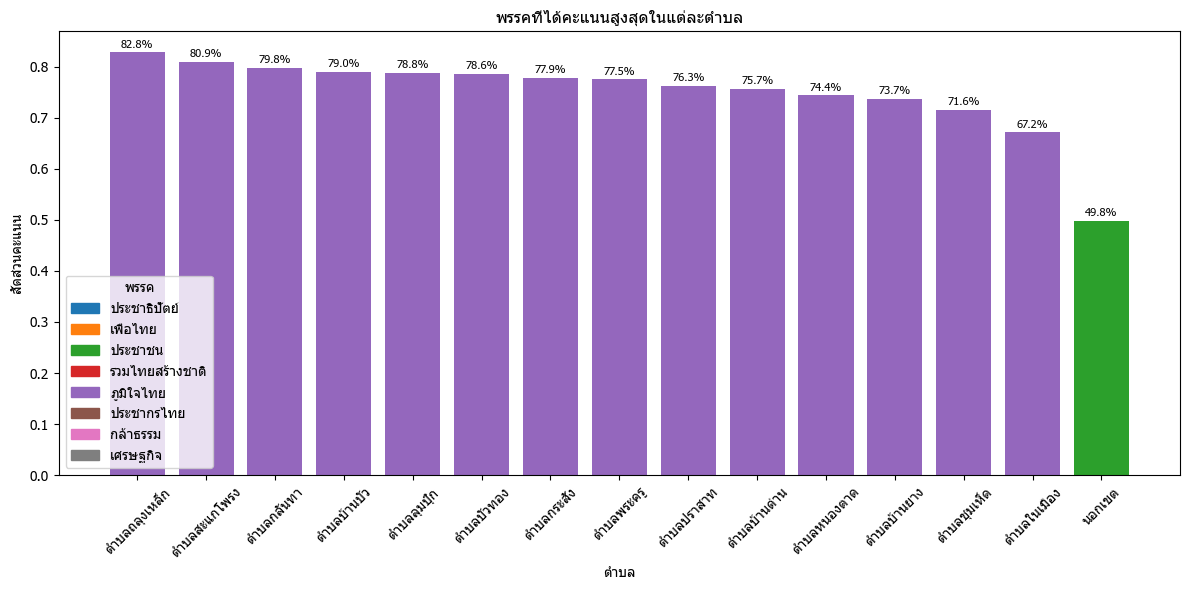

In [20]:
total_votes = district_scores.groupby('ตำบล')['คะแนน'].sum().reset_index(name='total_votes')
party_votes = district_scores.groupby(['ตำบล', 'พรรค'])['คะแนน'].sum().reset_index()

merged = party_votes.merge(total_votes, on='ตำบล')
merged['สัดส่วนคะแนน'] = merged['คะแนน'] / merged['total_votes']

top_party = merged.sort_values('สัดส่วนคะแนน', ascending=False).drop_duplicates('ตำบล')

party_colors = {p: c for p, c in zip(district_scores['พรรค'].unique(),plt.cm.tab10.colors)}

colors = top_party['พรรค'].map(party_colors)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(top_party)), top_party['สัดส่วนคะแนน'], color=colors)

for i, v in enumerate(top_party['สัดส่วนคะแนน']):
    plt.text(i, v + 0.005, f"{v*100:.1f}%", ha='center', va='bottom', fontsize=8)

plt.xticks(range(len(top_party)), top_party['ตำบล'], rotation=45)
plt.title('พรรคที่ได้คะแนนสูงสุดในแต่ละตำบล')
plt.xlabel('ตำบล')
plt.ylabel('สัดส่วนคะแนน')

handles = [plt.Rectangle((0,0),1,1, color=c) for c in party_colors.values()]
plt.legend(handles, party_colors.keys(), title='พรรค')

plt.tight_layout()
plt.show()

### 7. 5 หน่วยฐานเสียงแข็ง และ 5 หน่วยที่ต้องพัฒนาของแต่ละพรรค

0    0.247619
Name: margin_pct, dtype: float64
4    0.820690
3    0.838462
2    0.839416
1    0.849462
0    0.934211
Name: margin_pct, dtype: float64


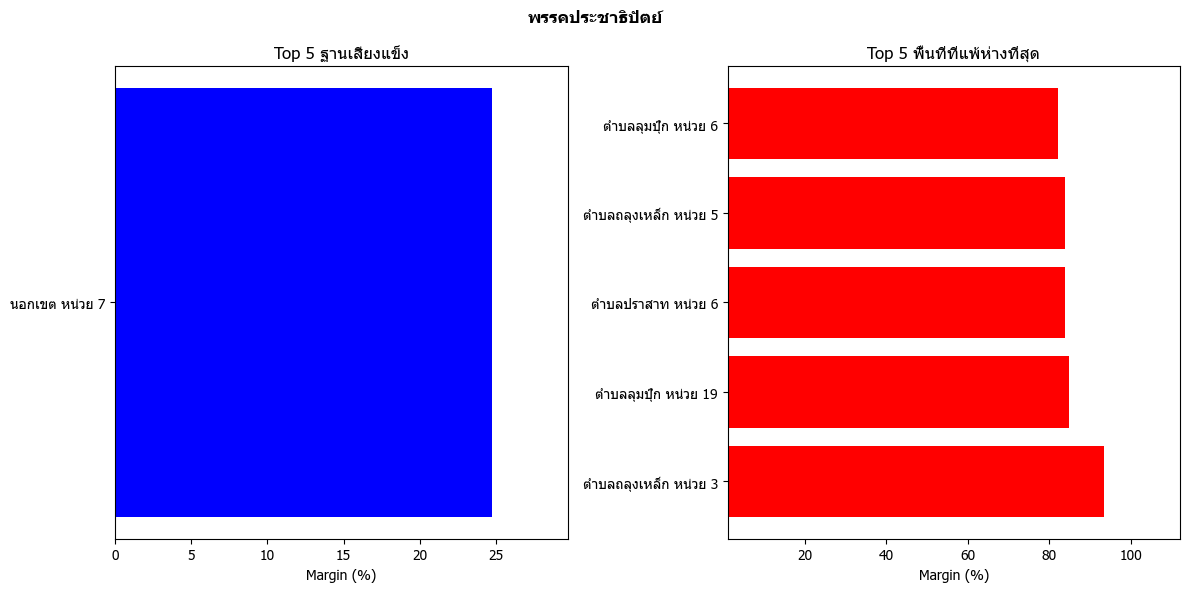

4    0.820690
3    0.838462
2    0.839416
1    0.849462
0    0.934211
Name: margin_pct, dtype: float64


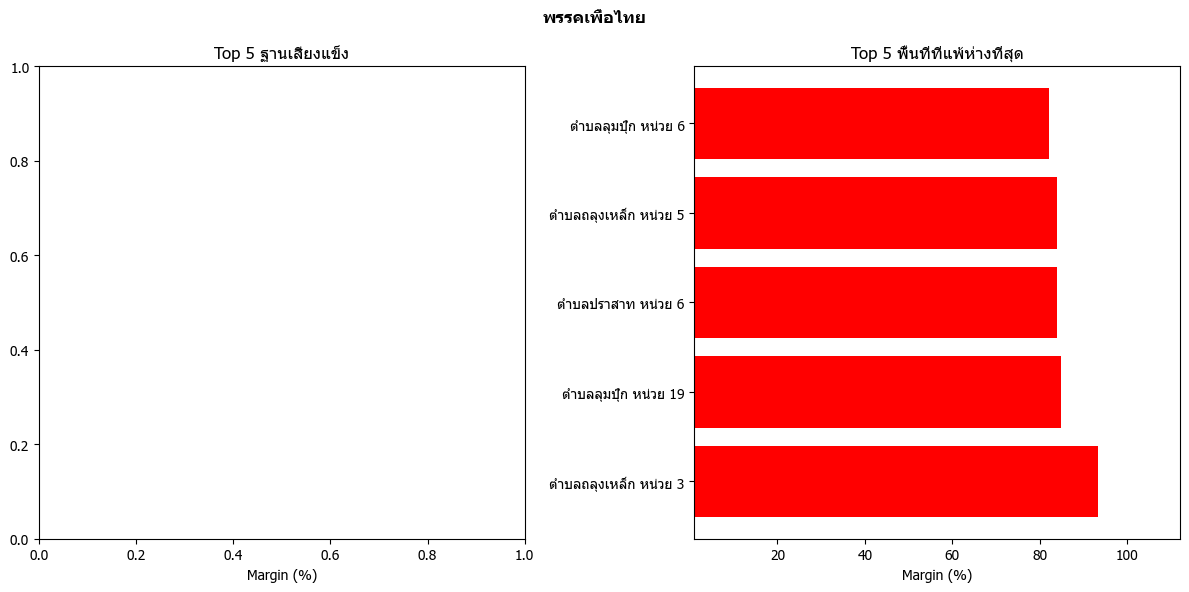

4    0.251981
3    0.260664
2    0.274322
1    0.277372
0    0.345146
Name: margin_pct, dtype: float64
4    0.820690
3    0.838462
2    0.839416
1    0.849462
0    0.934211
Name: margin_pct, dtype: float64


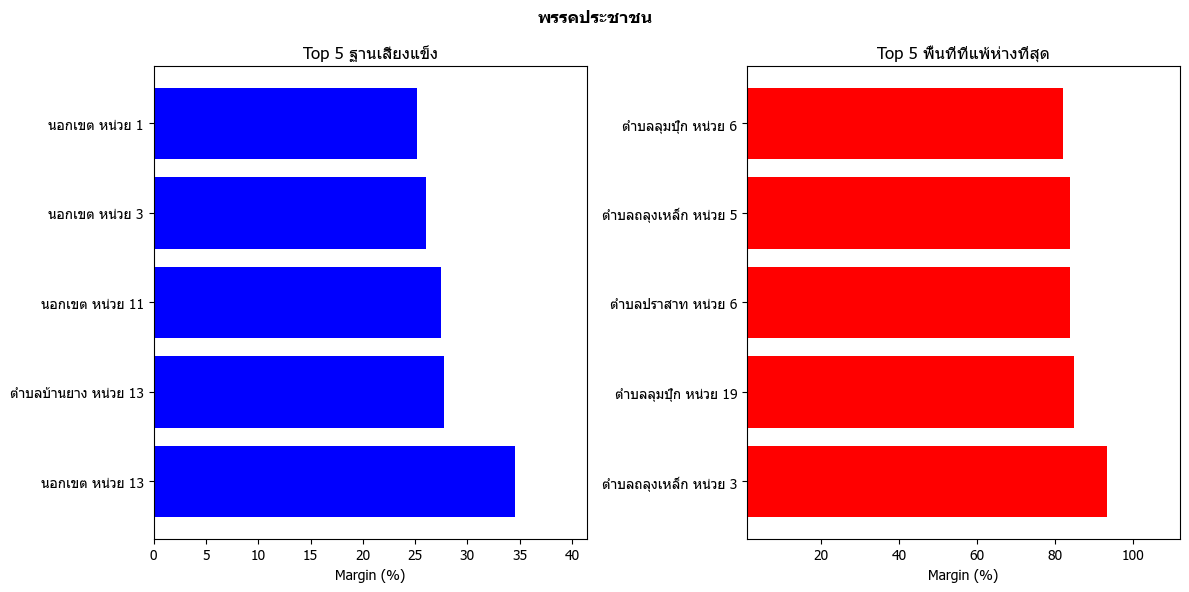

4    0.820690
3    0.838462
2    0.839416
1    0.849462
0    0.934211
Name: margin_pct, dtype: float64


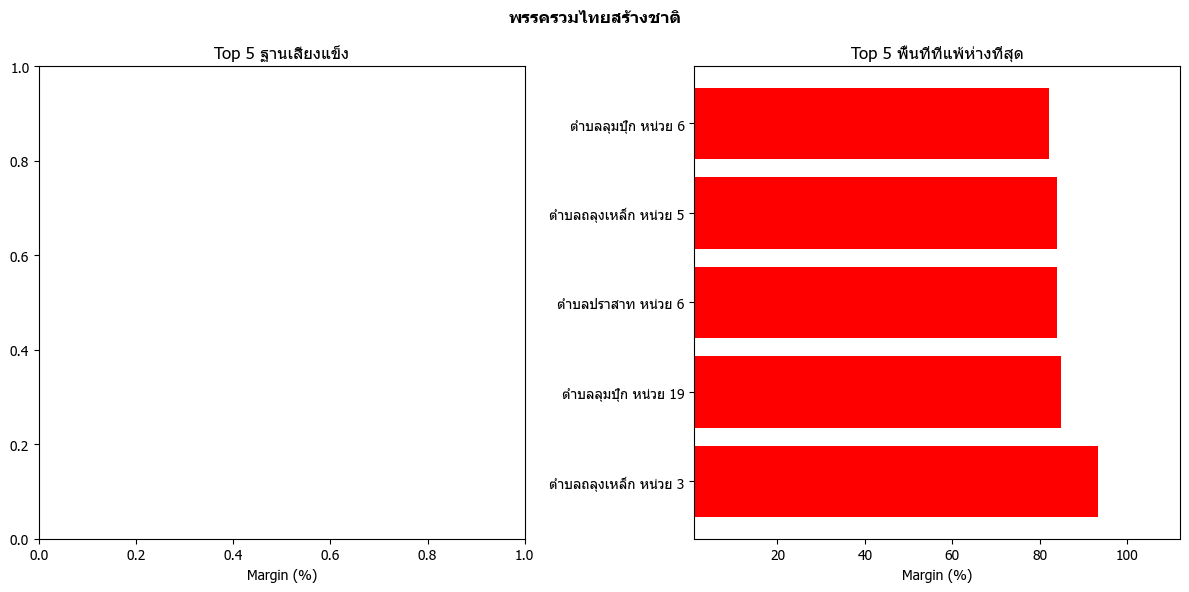

4    0.820690
3    0.838462
2    0.839416
1    0.849462
0    0.934211
Name: margin_pct, dtype: float64
4    0.251981
3    0.260664
2    0.274322
1    0.277372
0    0.345146
Name: margin_pct, dtype: float64


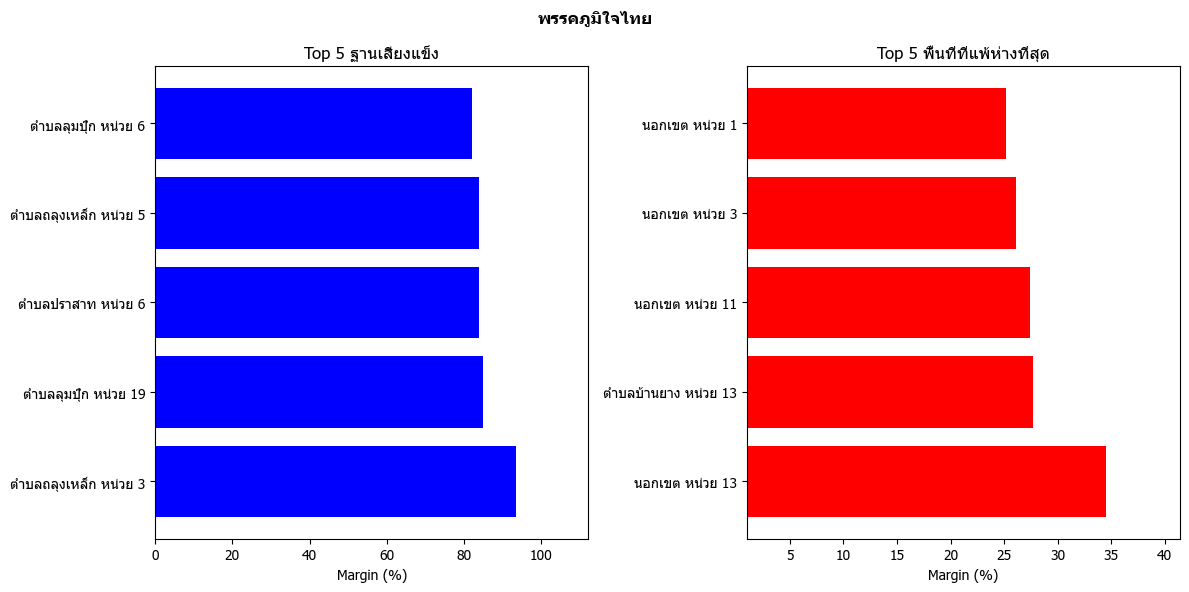

4    0.820690
3    0.838462
2    0.839416
1    0.849462
0    0.934211
Name: margin_pct, dtype: float64


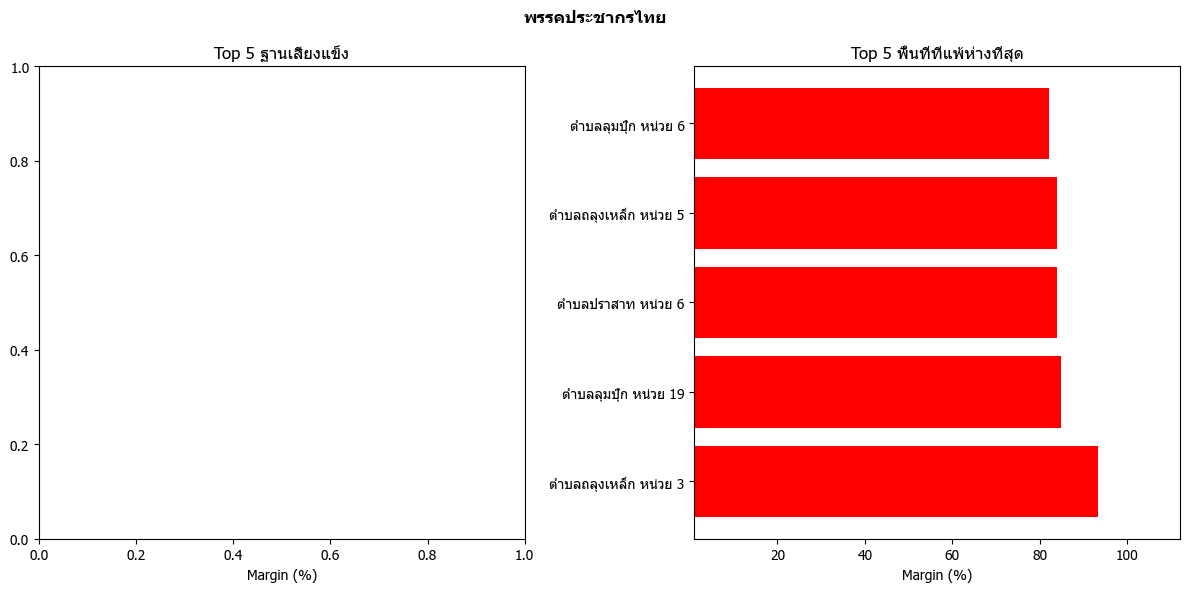

4    0.820690
3    0.838462
2    0.839416
1    0.849462
0    0.934211
Name: margin_pct, dtype: float64


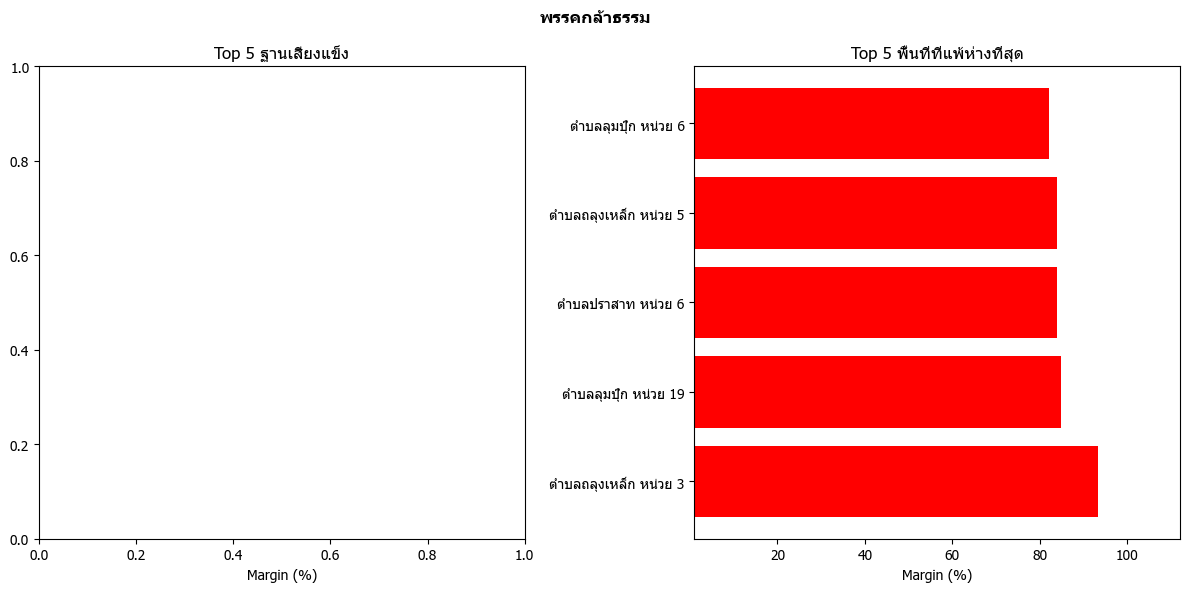

4    0.820690
3    0.838462
2    0.839416
1    0.849462
0    0.934211
Name: margin_pct, dtype: float64


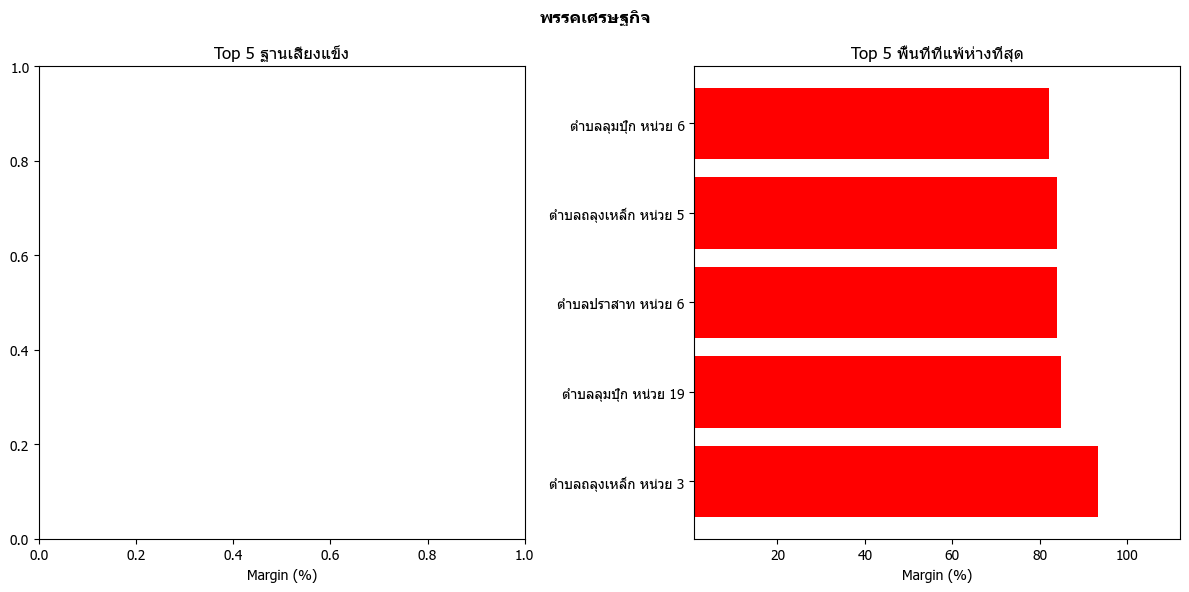

In [21]:
TOP_UNIT = 5

def calc_margin(group):
    group = group.sort_values("คะแนน", ascending=False).reset_index(drop=True)
    if len(group) < 2:
        return pd.Series({"winner": group.loc[0, "ชื่อผู้สมัคร"], "พรรค": group.loc[0, "พรรค"],
                          "winner_score": group.loc[0, "คะแนน"], "margin": group.loc[0, "คะแนน"], "margin_pct": 1.0})
    margin = group.loc[0, "คะแนน"] - group.loc[1, "คะแนน"]
    total = group["คะแนน"].sum()
    return pd.Series({"winner": group.loc[0, "ชื่อผู้สมัคร"], "พรรค": group.loc[0, "พรรค"],
                      "winner_score": group.loc[0, "คะแนน"], "margin": margin, "margin_pct": margin / total})

unit_margin = district_scores.groupby("unit_key").apply(calc_margin, include_groups=False).reset_index()
unit_margin = unit_margin.merge(district_scores[["unit_key", "หน่วย", "ตำบล", "อำเภอ"]].drop_duplicates(), on="unit_key")

parties = district_scores["พรรค"].unique()

for party in parties:
    own = unit_margin[unit_margin["พรรค"] == party].copy()
    lost = unit_margin[unit_margin["พรรค"] != party].copy()
    own_sorted = own.sort_values("margin_pct", ascending=False).head(TOP_UNIT).reset_index(drop=True)
    lost_sorted = lost.sort_values("margin_pct", ascending=False).head(TOP_UNIT).reset_index(drop=True)

    if own_sorted.empty and lost_sorted.empty:
        continue

    n_rows = max(len(own_sorted), len(lost_sorted), 1)
    fig_height = max(4, n_rows * 1.2)

    fig, axes = plt.subplots(1, 2, figsize=(12, fig_height))
    fig.suptitle(f"พรรค{party}", fontweight="bold")

    if not own_sorted.empty:
        own_sorted = own_sorted.dropna(subset=["ตำบล", "หน่วย"]).reset_index(drop=True)
        print(own_sorted["margin_pct"].sort_values())
        values = own_sorted["margin_pct"] * 100
        axes[0].barh(own_sorted["ตำบล"] + " หน่วย " + own_sorted["หน่วย"], values, color="blue")
        axes[0].set_xlim(0, values.max() * 1.2)

    axes[0].set_xlabel("Margin (%)")
    axes[0].set_title(f"Top {TOP_UNIT} ฐานเสียงแข็ง")

    if not lost_sorted.empty:
        lost_sorted = lost_sorted.dropna(subset=["ตำบล", "หน่วย"]).reset_index(drop=True)
        print(lost_sorted["margin_pct"].sort_values())
        values = lost_sorted["margin_pct"] * 100
        axes[1].barh(lost_sorted["ตำบล"] + " หน่วย " + lost_sorted["หน่วย"],values, color="red")
        axes[1].set_xlim(1, values.max() * 1.2)

    axes[1].set_xlabel("Margin (%)")
    axes[1].set_title(f"Top {TOP_UNIT} พื้นที่ที่แพ้ห่างที่สุด")

    plt.tight_layout()
    plt.show()

## บัญชีรายชื่อ

In [22]:
TOP = 10

### 1. คะแนนรวมแต่ละพรรค (Top 10)

,คะแนน,% คะแนน
พรรค,,
ภูมิใจไทย,47877,62.599861
ประชาชน,16685,21.815876
เพื่อไทย,4980,6.511421
รวมใจไทย,1967,2.571881
เศรษฐกิจ,1606,2.099868
ประชาธิปัตย์,1115,1.457878
รวมไทยสร้างชาติ,718,0.938795
ประชาธิปไตยใหม่,602,0.787124
เพื่อชาติไทย,534,0.698213


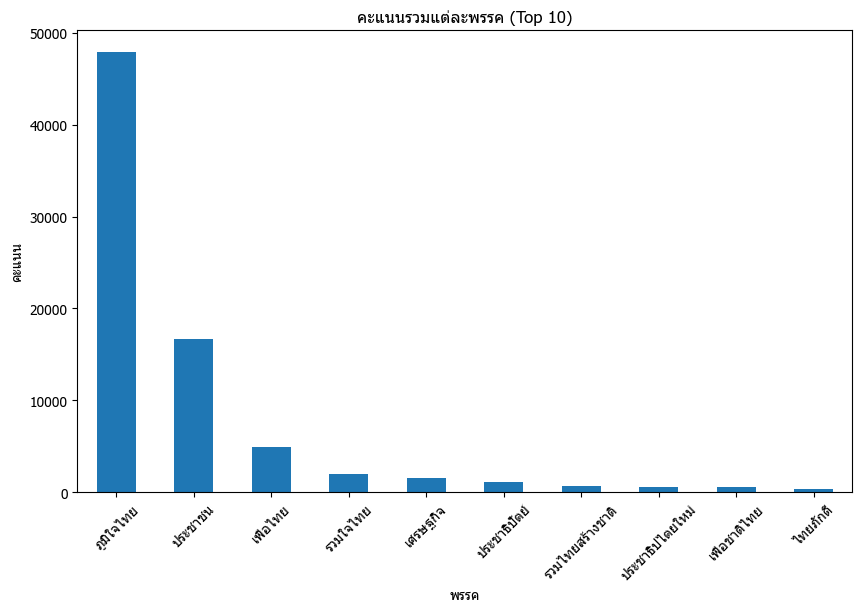

In [23]:
party_total_top = partylist_scores.groupby("พรรค")["คะแนน"].sum().sort_values(ascending=False).head(TOP)
party_total_top_df = pd.DataFrame(party_total_top, columns=["คะแนน"])
party_total_top_df["% คะแนน"] = party_total_top_df["คะแนน"] / party_total_top_df["คะแนน"].sum() * 100
display(party_total_top_df)

plt.figure(figsize=(10,6))
party_total_top.plot(kind="bar")
plt.title(f"คะแนนรวมแต่ละพรรค (Top {TOP})")
plt.ylabel("คะแนน")
plt.xticks(rotation=45)
plt.show()

### 2. จำนวนหน่วยที่แต่ละพรรคชนะ (Top 10)

พรรค
ภูมิใจไทย    24
ประชาชน       8
Name: count, dtype: int64

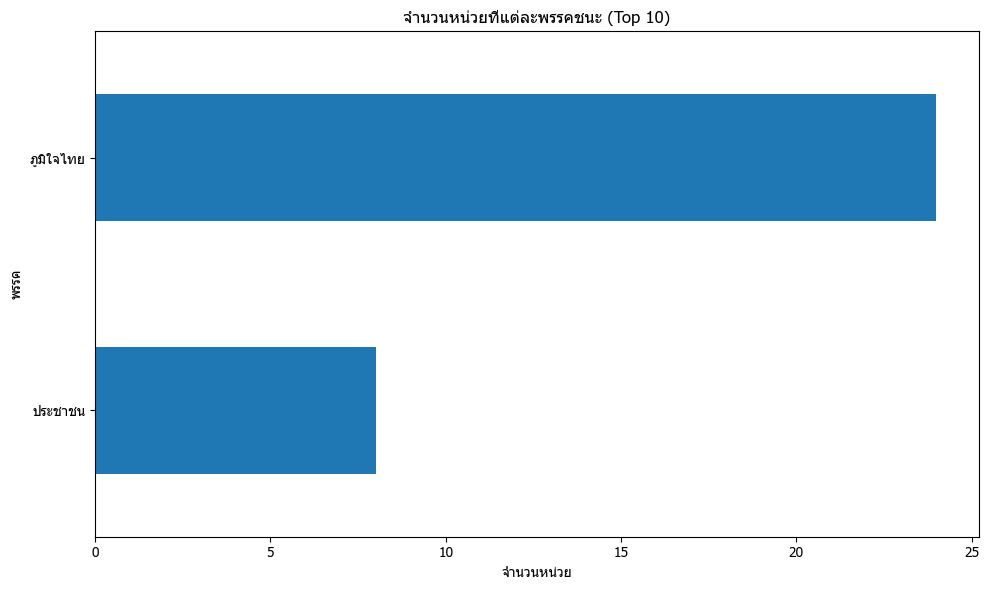

In [24]:
winner_unit = partylist_scores.loc[
    partylist_scores.groupby("หน่วย")["คะแนน"].idxmax()
]

win_count = winner_unit["พรรค"].value_counts().head(TOP)

display(win_count)

plt.figure(figsize=(10,6))
win_count.sort_values().plot(kind="barh")
plt.title(f"จำนวนหน่วยที่แต่ละพรรคชนะ (Top {TOP})")
plt.xlabel("จำนวนหน่วย")
plt.ylabel("พรรค")
plt.tight_layout()
plt.show()

### 3. พรรคที่ชนะในแต่ละตำบล

In [25]:
winner = partylist_scores.loc[partylist_scores.groupby("ตำบล")["คะแนน"].idxmax()][["ตำบล", "พรรค", "คะแนน"]]
display(winner.sort_values("ตำบล"))

,ตำบล,พรรค,คะแนน
2601,ตำบลกระสัง,ภูมิใจไทย,321
3513,ตำบลกลันทา,ภูมิใจไทย,282
4767,ตำบลชุมเห็ด,ภูมิใจไทย,313
6078,ตำบลถลุงเหล็ก,ภูมิใจไทย,188
8472,ตำบลบัวทอง,ภูมิใจไทย,248
492,ตำบลบ้านด่าน,ภูมิใจไทย,363
9384,ตำบลบ้านบัว,ภูมิใจไทย,384
10695,ตำบลบ้านยาง,ภูมิใจไทย,296
2145,ตำบลปราสาท,ภูมิใจไทย,263
11892,ตำบลพระครู,ภูมิใจไทย,282


### 4. การกระจายคะแนนพรรคในแต่ละตำบล (Top 10 ของแต่ละตำบล)

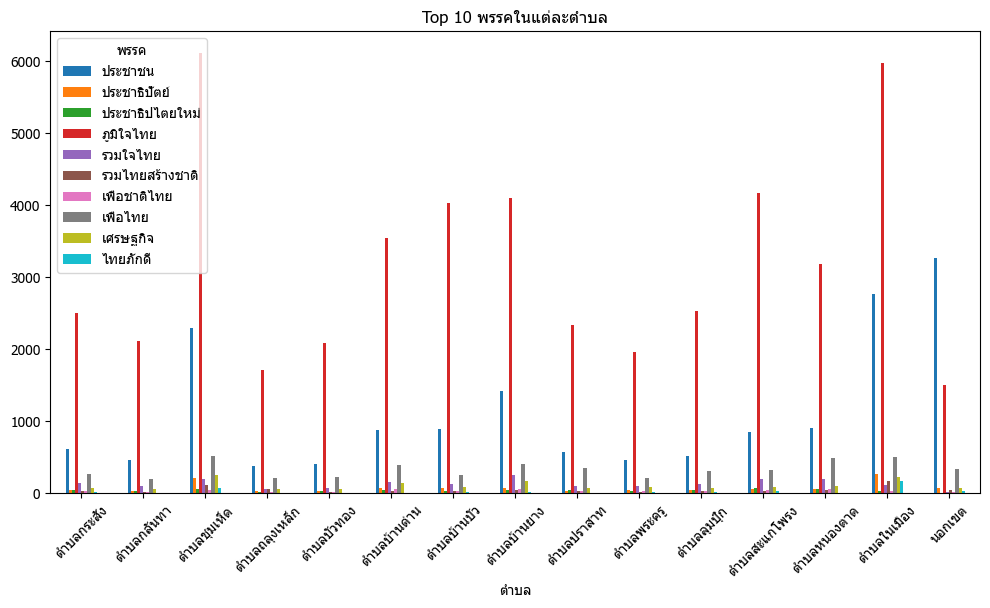

In [26]:
top = partylist_scores.groupby("พรรค")["คะแนน"].sum().nlargest(TOP).index
df_top = partylist_scores[partylist_scores["พรรค"].isin(top)]

pivot = df_top.pivot_table(index="ตำบล", columns="พรรค", values="คะแนน", aggfunc="sum",fill_value=0)

pivot.plot(kind="bar", figsize=(12,6))
plt.title(f"Top {TOP} พรรคในแต่ละตำบล")
plt.xticks(rotation=45)
plt.show()

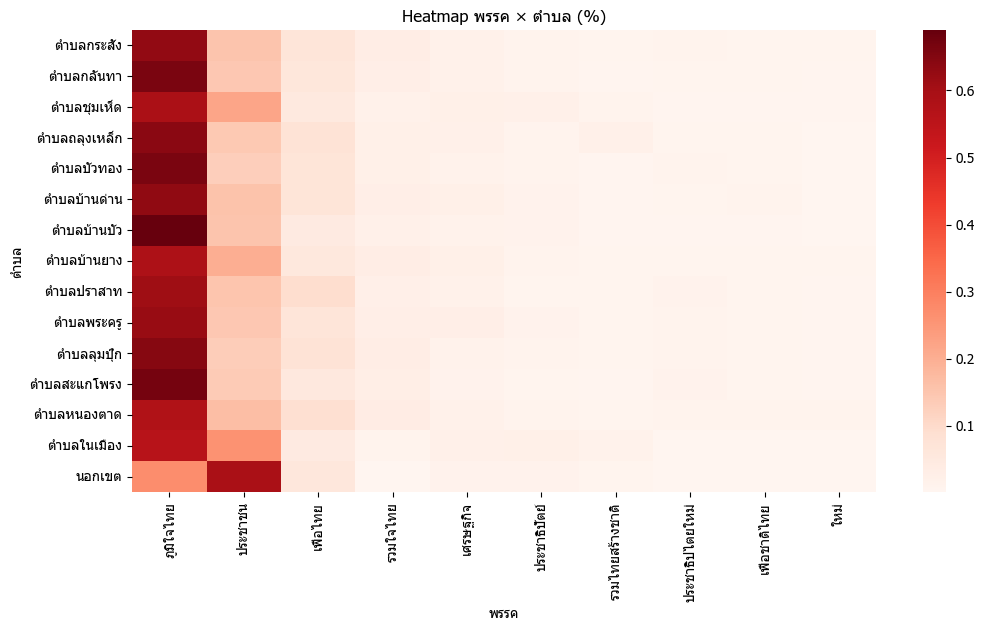

In [27]:
pivot = partylist_scores.pivot_table(index="ตำบล",columns="พรรค",values="คะแนน",aggfunc="sum",fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

top = pivot_pct.sum().nlargest(TOP).index
pivot_pct = pivot_pct[top]

plt.figure(figsize=(12,6))
sns.heatmap(pivot_pct, cmap="Reds")
plt.title("Heatmap พรรค × ตำบล (%)")
plt.show()

### 5. บัตรเสียรายตำบล

In [28]:
partylist_tambon = partylist_summary.groupby("ตำบล").agg({
        "บัตรเสีย": "sum",
        "จำนวนบัตรทั้งหมด": "sum"
    }).reset_index()

partylist_tambon["invalid_pct"] = (partylist_tambon["บัตรเสีย"] / partylist_tambon["จำนวนบัตรทั้งหมด"]
                                   ).replace([np.inf, -np.inf], np.nan)


total_bad = partylist_tambon["บัตรเสีย"].sum()
partylist_tambon["invalid_share"] = (partylist_tambon["บัตรเสีย"] / total_bad)

partylist_tambon = partylist_tambon.sort_values("บัตรเสีย", ascending=False)

display(partylist_tambon)

,ตำบล,บัตรเสีย,จำนวนบัตรทั้งหมด,invalid_pct,invalid_share
2,ตำบลชุมเห็ด,480,15990,0.030019,0.127355
13,ตำบลในเมือง,381,16473,0.023129,0.101088
5,ตำบลบ้านด่าน,351,9240,0.037987,0.093128
7,ตำบลบ้านยาง,325,11400,0.028509,0.086230
12,ตำบลหนองตาด,321,9160,0.035044,0.085168
11,ตำบลสะแกโพรง,311,10640,0.029229,0.082515
8,ตำบลปราสาท,274,6900,0.039710,0.072698
0,ตำบลกระสัง,263,6140,0.042834,0.069780
6,ตำบลบ้านบัว,241,8241,0.029244,0.063943
9,ตำบลพระครู,189,5420,0.034871,0.050146


### 6. พรรคที่ชนะในแต่ละตำบล

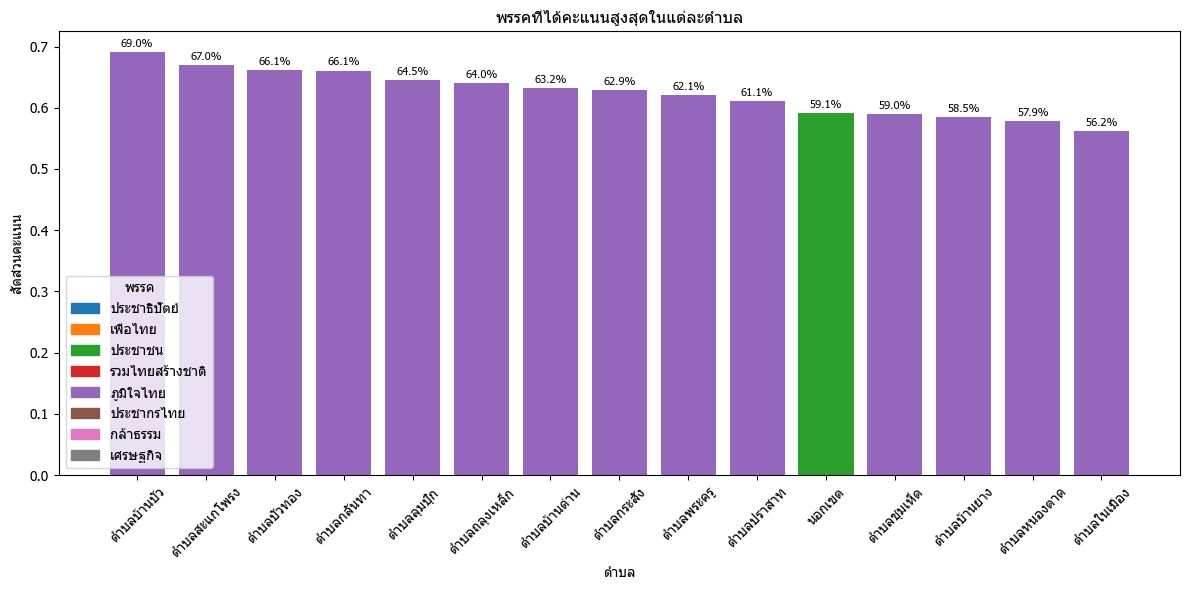

In [29]:
total_votes = partylist_scores.groupby('ตำบล')['คะแนน'].sum().reset_index(name='total_votes')
party_votes = partylist_scores.groupby(['ตำบล', 'พรรค'])['คะแนน'].sum().reset_index()

merged = party_votes.merge(total_votes, on='ตำบล')
merged['สัดส่วนคะแนน'] = merged['คะแนน'] / merged['total_votes']

top_party = merged.sort_values('สัดส่วนคะแนน', ascending=False).drop_duplicates('ตำบล')

party_colors = {p: c for p, c in zip(district_scores['พรรค'].unique(),plt.cm.tab10.colors)}

colors = top_party['พรรค'].map(party_colors)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(top_party)), top_party['สัดส่วนคะแนน'], color=colors)

for i, v in enumerate(top_party['สัดส่วนคะแนน']):
    plt.text(i, v + 0.005, f"{v*100:.1f}%", ha='center', va='bottom', fontsize=8)

plt.xticks(range(len(top_party)), top_party['ตำบล'], rotation=45)
plt.title('พรรคที่ได้คะแนนสูงสุดในแต่ละตำบล')
plt.xlabel('ตำบล')
plt.ylabel('สัดส่วนคะแนน')

handles = [plt.Rectangle((0,0),1,1, color=c) for c in party_colors.values()]
plt.legend(handles, party_colors.keys(), title='พรรค')

plt.tight_layout()
plt.show()

### 7. 5 หน่วยฐานเสียงแข็ง และ 5 หน่วยที่ต้องพัฒนาของแต่ละพรรค (พรรคที่ได้คะแนน Top 10)

4    0.705882
3    0.712121
2    0.723529
1    0.763889
0    0.914216
Name: margin_pct, dtype: float64
4    0.309696
3    0.327586
2    0.334311
1    0.398268
0    0.522936
Name: margin_pct, dtype: float64


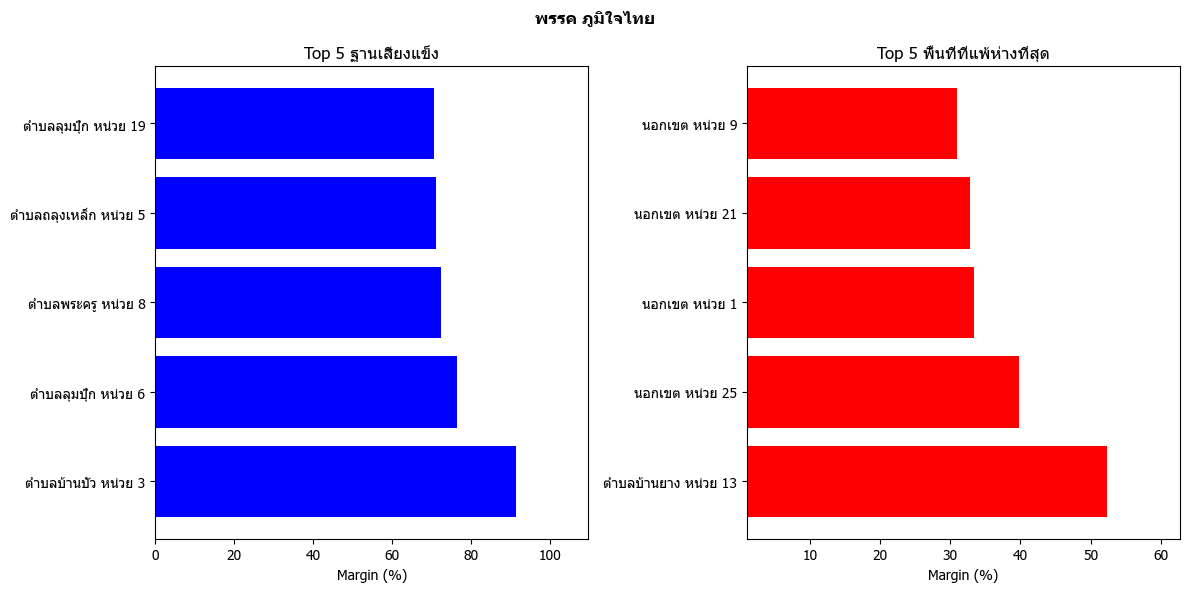

4    0.309696
3    0.327586
2    0.334311
1    0.398268
0    0.522936
Name: margin_pct, dtype: float64
4    0.705882
3    0.712121
2    0.723529
1    0.763889
0    0.914216
Name: margin_pct, dtype: float64


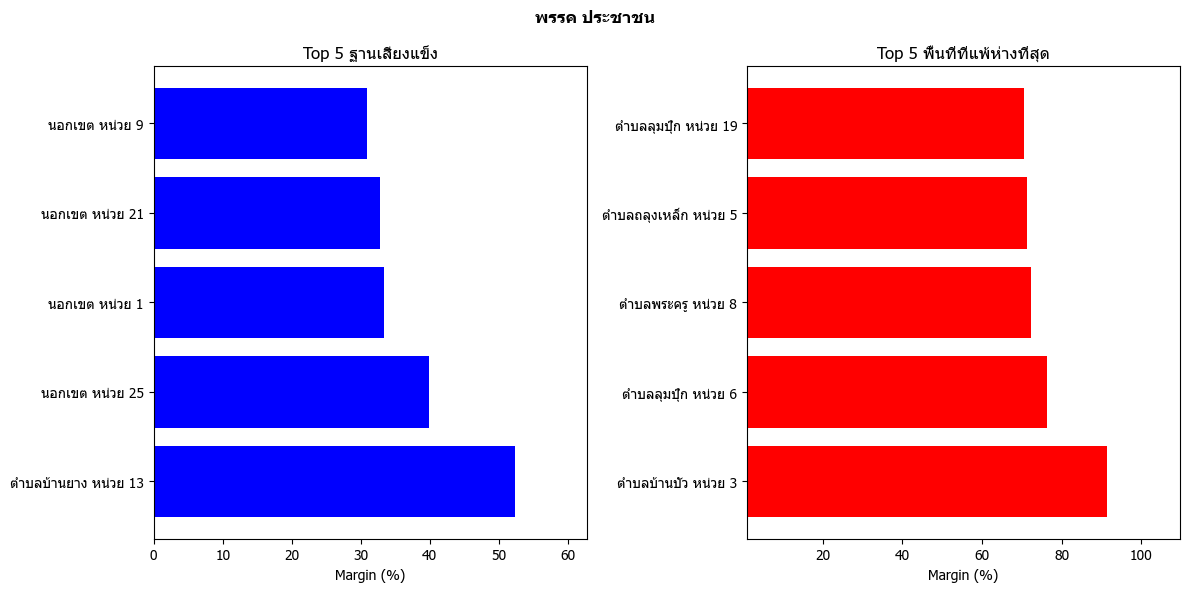

4    0.705882
3    0.712121
2    0.723529
1    0.763889
0    0.914216
Name: margin_pct, dtype: float64


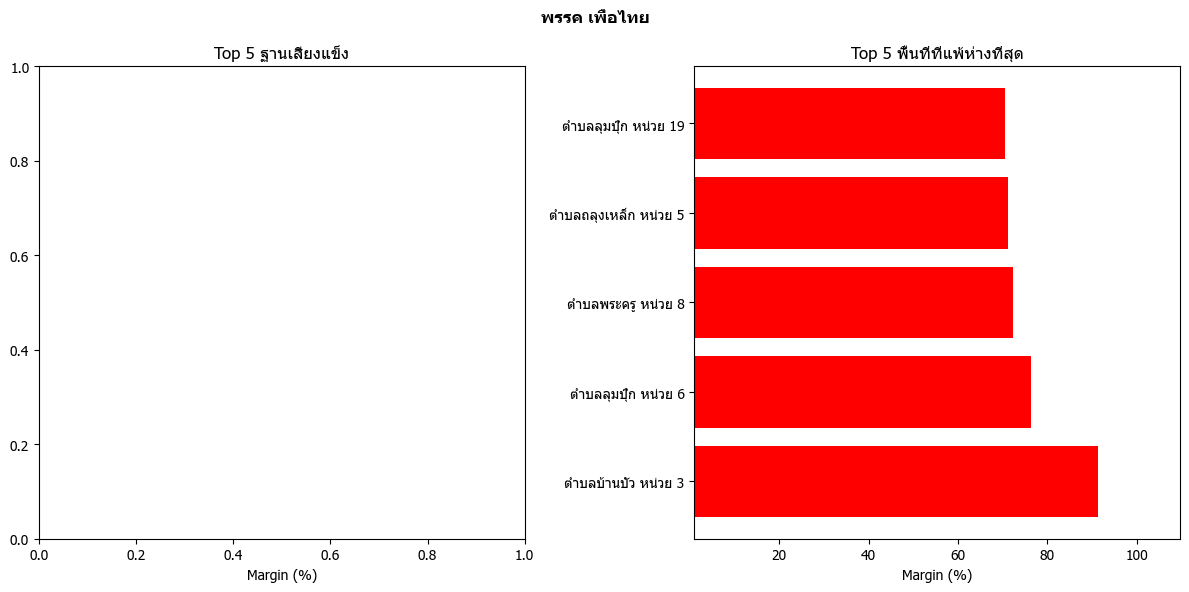

4    0.705882
3    0.712121
2    0.723529
1    0.763889
0    0.914216
Name: margin_pct, dtype: float64


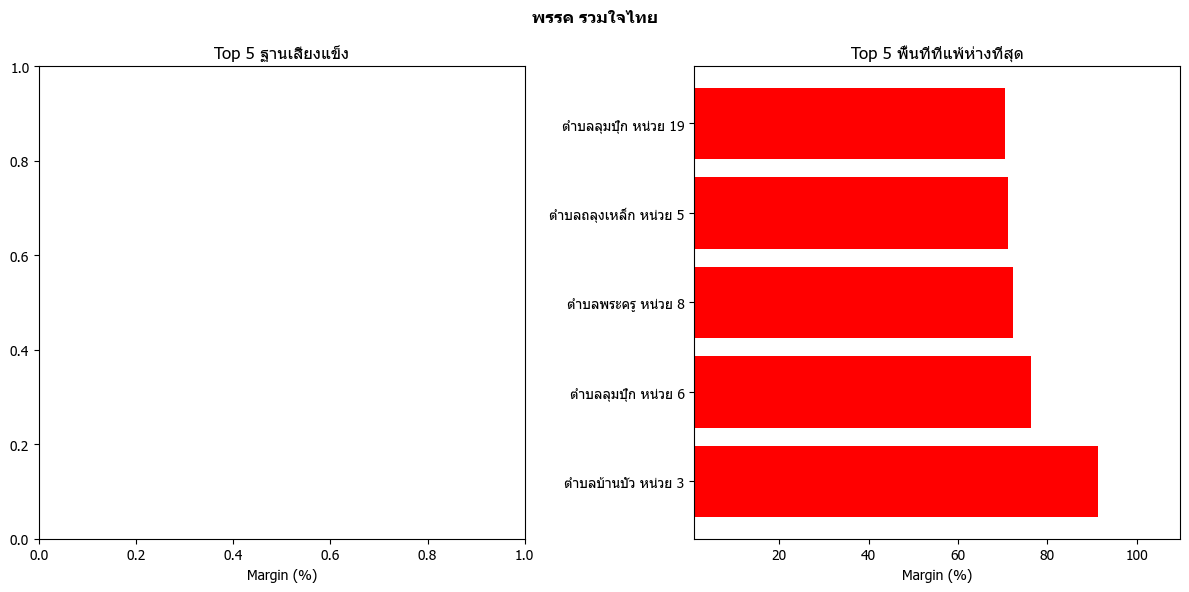

4    0.705882
3    0.712121
2    0.723529
1    0.763889
0    0.914216
Name: margin_pct, dtype: float64


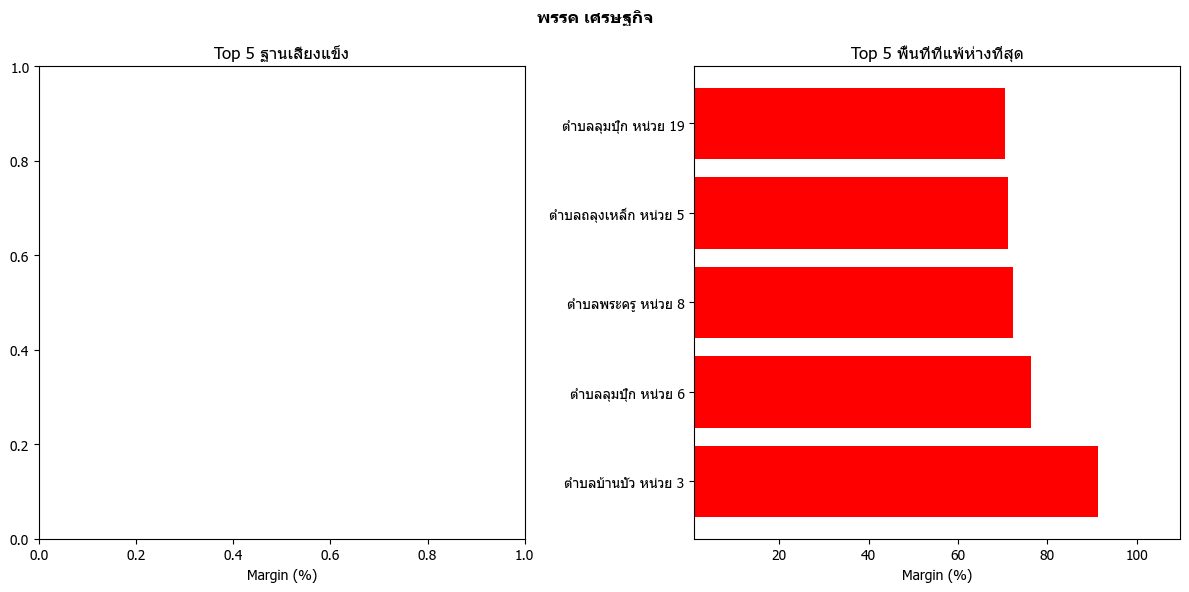

4    0.705882
3    0.712121
2    0.723529
1    0.763889
0    0.914216
Name: margin_pct, dtype: float64


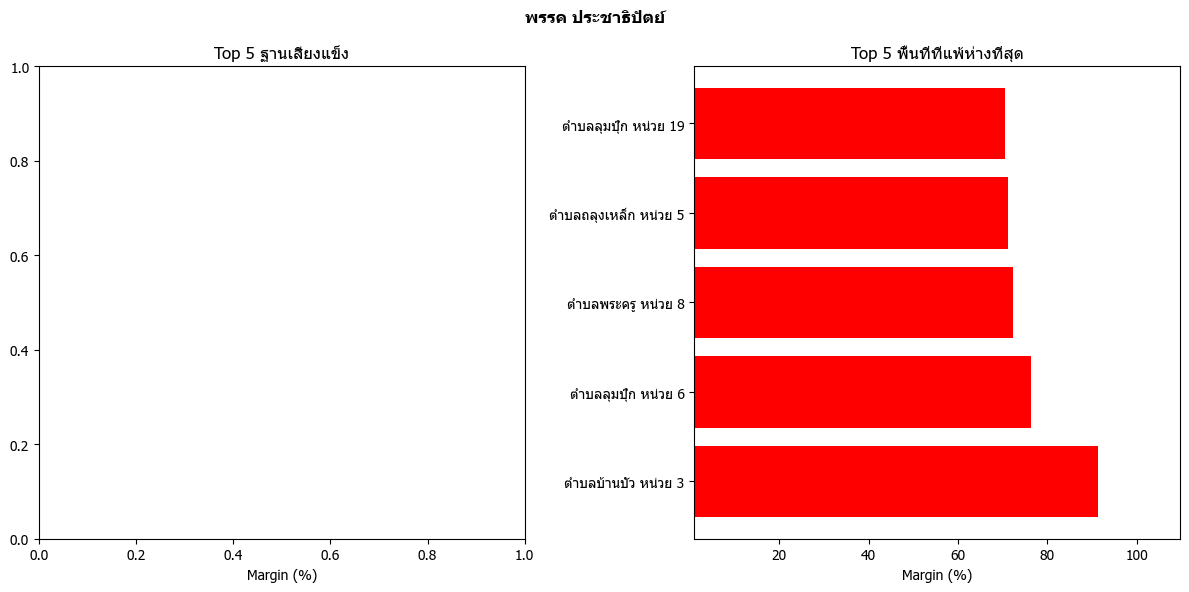

4    0.705882
3    0.712121
2    0.723529
1    0.763889
0    0.914216
Name: margin_pct, dtype: float64


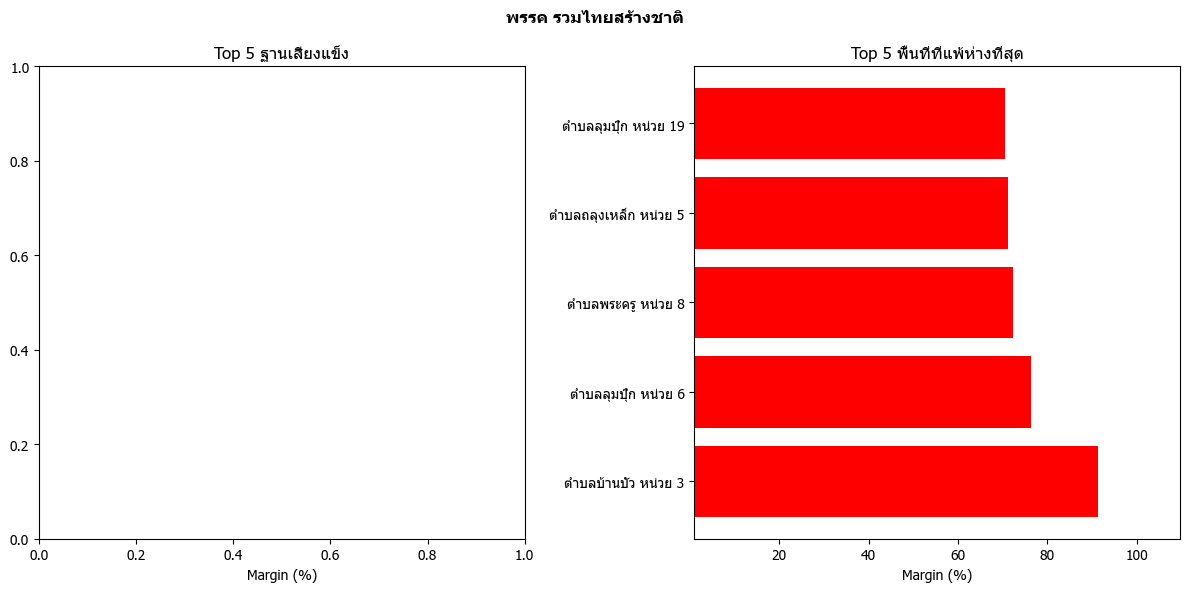

4    0.705882
3    0.712121
2    0.723529
1    0.763889
0    0.914216
Name: margin_pct, dtype: float64


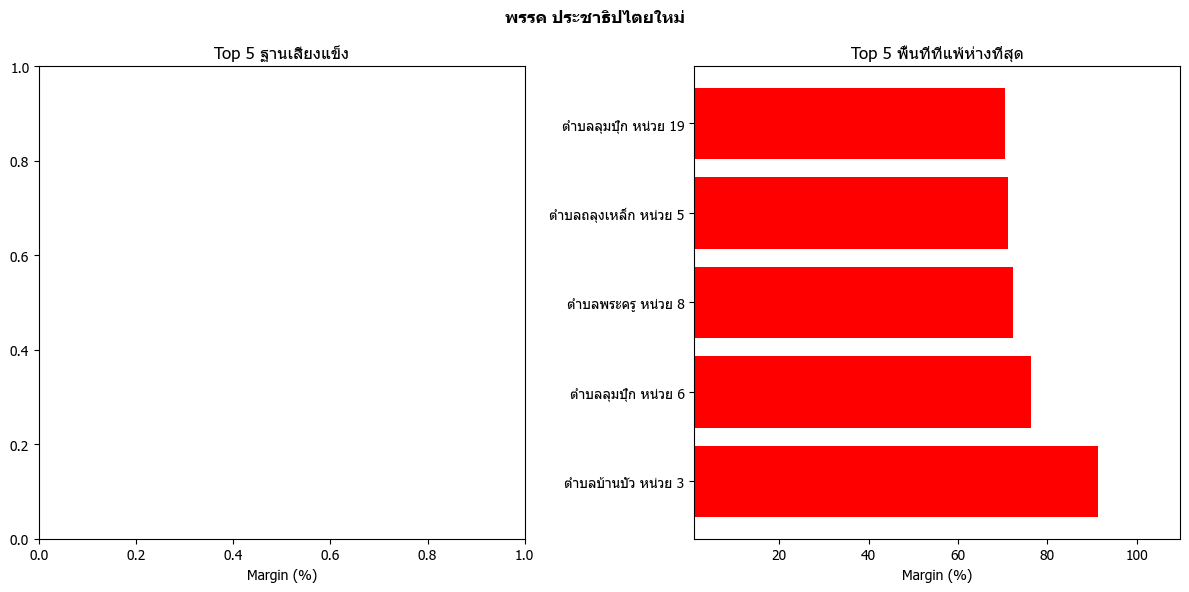

4    0.705882
3    0.712121
2    0.723529
1    0.763889
0    0.914216
Name: margin_pct, dtype: float64


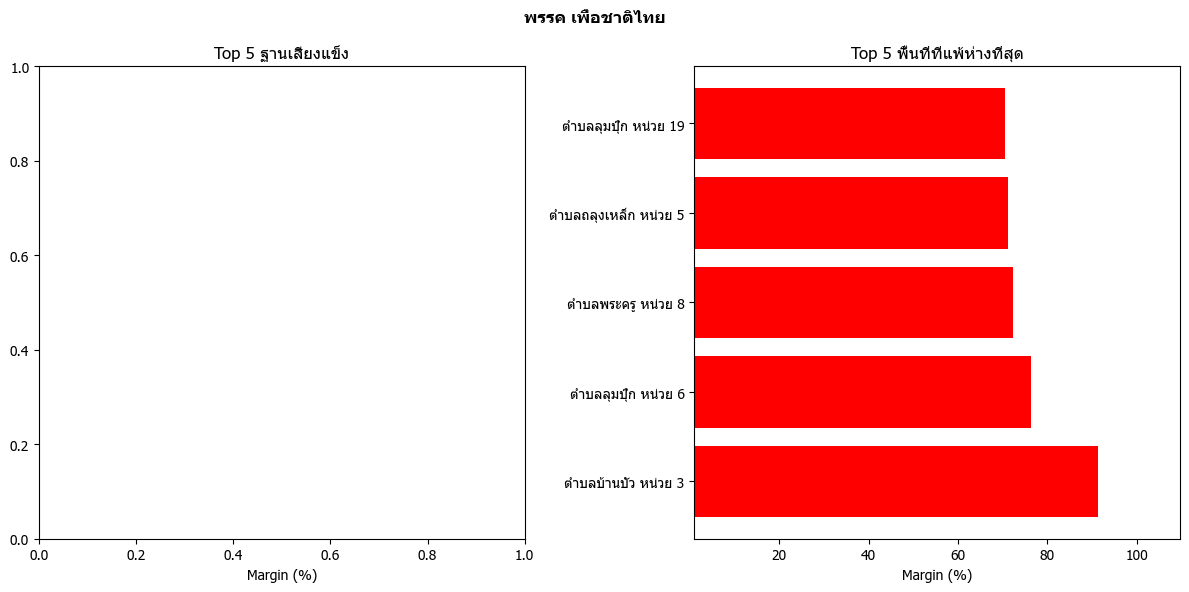

4    0.705882
3    0.712121
2    0.723529
1    0.763889
0    0.914216
Name: margin_pct, dtype: float64


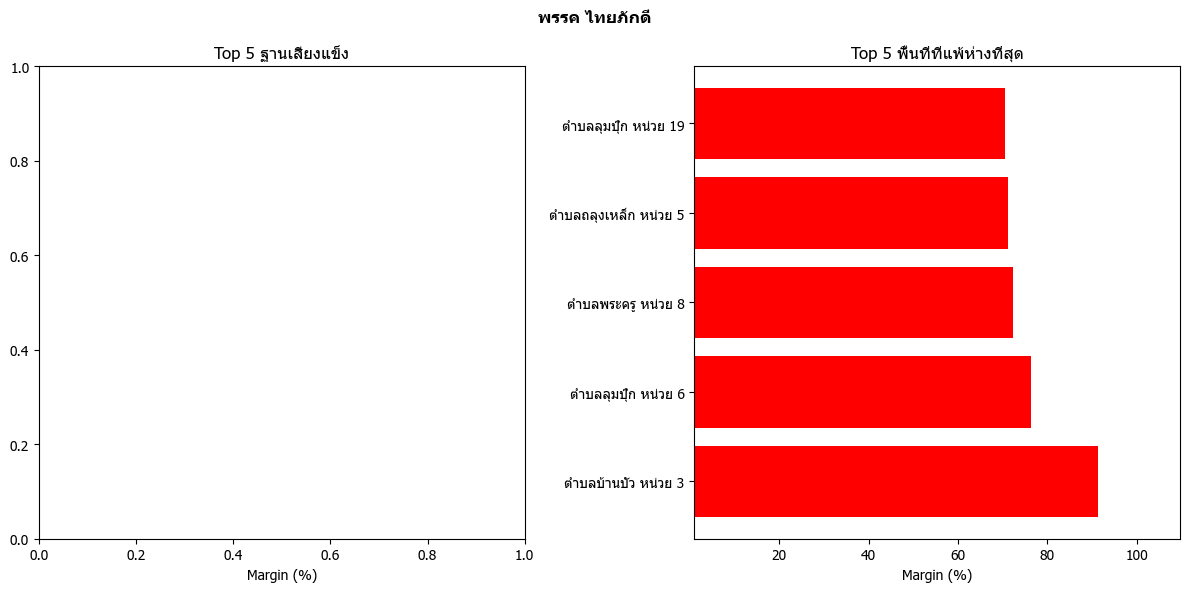

In [30]:
TOP_UNIT = 5

top_parties = partylist_scores.groupby("พรรค")["คะแนน"].sum().nlargest(TOP).index

def calc_margin_partylist(group):
    group = group.sort_values("คะแนน", ascending=False).reset_index(drop=True)
    
    if len(group) < 2:
        return pd.Series({
            "winner": group.loc[0, "พรรค"],
            "winner_score": group.loc[0, "คะแนน"],
            "margin": group.loc[0, "คะแนน"],
            "margin_pct": 1.0
        })
    
    margin = group.loc[0, "คะแนน"] - group.loc[1, "คะแนน"]
    total = group["คะแนน"].sum()
    
    return pd.Series({
        "winner": group.loc[0, "พรรค"],
        "winner_score": group.loc[0, "คะแนน"],
        "margin": margin,
        "margin_pct": margin / total
    })

unit_margin = partylist_scores.groupby("unit_key").apply(calc_margin_partylist, include_groups=False).reset_index()
unit_margin = unit_margin.merge(partylist_scores[["unit_key", "หน่วย", "ตำบล", "อำเภอ"]].drop_duplicates(), on="unit_key")

for party in top_parties:
    own = unit_margin[unit_margin["winner"] == party].copy()
    lost = unit_margin[unit_margin["winner"] != party].copy()

    own_sorted = own.sort_values("margin_pct", ascending=False).head(TOP_UNIT).reset_index(drop=True)
    lost_sorted = lost.sort_values("margin_pct", ascending=False).head(TOP_UNIT).reset_index(drop=True)

    if own_sorted.empty and lost_sorted.empty:
        continue

    n_rows = max(len(own_sorted), len(lost_sorted), 1)
    fig_height = max(4, n_rows * 1.2)

    fig, axes = plt.subplots(1, 2, figsize=(12, fig_height))
    fig.suptitle(f"พรรค {party}", fontweight="bold")

    if not own_sorted.empty:
        own_sorted = own_sorted.dropna(subset=["ตำบล", "หน่วย"]).reset_index(drop=True)
        print(own_sorted["margin_pct"].sort_values())
        values = own_sorted["margin_pct"] * 100
        axes[0].barh(own_sorted["ตำบล"] + " หน่วย " + own_sorted["หน่วย"], values, color="blue")
        axes[0].set_xlim(0, values.max() * 1.2)

    axes[0].set_xlabel("Margin (%)")
    axes[0].set_title(f"Top {TOP_UNIT} ฐานเสียงแข็ง")

    if not lost_sorted.empty:
        lost_sorted = lost_sorted.dropna(subset=["ตำบล", "หน่วย"]).reset_index(drop=True)
        print(lost_sorted["margin_pct"].sort_values())
        values = lost_sorted["margin_pct"] * 100
        axes[1].barh(lost_sorted["ตำบล"] + " หน่วย " + lost_sorted["หน่วย"],values, color="red")
        axes[1].set_xlim(1, values.max() * 1.2)

    axes[1].set_xlabel("Margin (%)")
    axes[1].set_title(f"Top {TOP_UNIT} พื้นที่ที่แพ้ห่างที่สุด")

    plt.tight_layout()
    plt.show()

## 3. ประชามติ

### 1. เห็นชอบ/ไม่เห็นชอบ รายตำบล

รายการ,เห็นชอบ,ไม่เห็นชอบ,ไม่แสดงความคิดเห็น,total_valid,pct_approve,winner
ตำบล,,,,,,
ตำบลกระสัง,1997.0,1535.0,450.0,3982.0,50.15,เห็นชอบ
ตำบลกลันทา,1516.0,1442.0,345.0,3303.0,45.90,เห็นชอบ
ตำบลชุมเห็ด,5191.0,4324.0,1113.0,10628.0,48.84,เห็นชอบ
ตำบลถลุงเหล็ก,1403.0,1049.0,294.0,2746.0,51.09,เห็นชอบ
ตำบลบัวทอง,1772.0,1096.0,352.0,3220.0,55.03,เห็นชอบ
ตำบลบ้านด่าน,2839.0,2393.0,568.0,5800.0,48.95,เห็นชอบ
ตำบลบ้านบัว,2738.0,2646.0,596.0,5980.0,45.79,เห็นชอบ
ตำบลบ้านยาง,3955.0,2542.0,757.0,7254.0,54.52,เห็นชอบ
ตำบลปราสาท,2145.0,1386.0,453.0,3984.0,53.84,เห็นชอบ


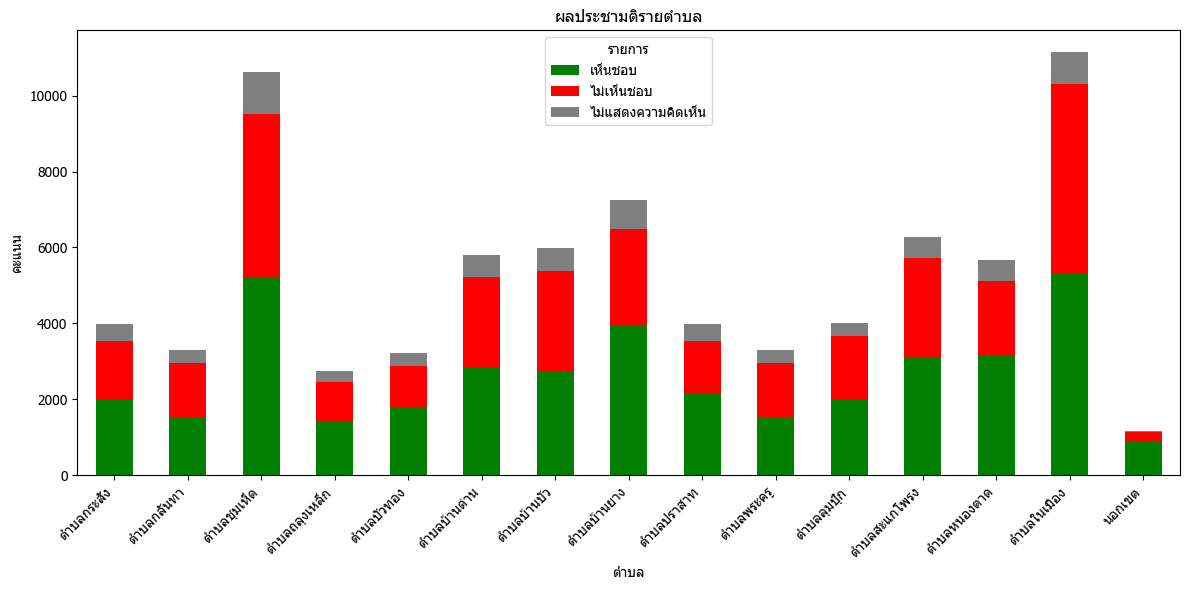

In [31]:
refer_tumbon = referendum_scores.groupby(["ตำบล", "รายการ"], as_index=False)["คะแนน"].sum()
r_pivot = refer_tumbon.pivot_table(index="ตำบล", columns="รายการ", values="คะแนน", fill_value=0)

if "เห็นชอบ" in r_pivot.columns:
    r_pivot["total_valid"] = r_pivot.sum(axis=1)
    r_pivot["pct_approve"] = (r_pivot["เห็นชอบ"] / r_pivot["total_valid"] * 100).round(2)

plot_cols = [c for c in ["เห็นชอบ", "ไม่เห็นชอบ", "ไม่แสดงความคิดเห็น"] if c in r_pivot.columns]
r_pivot["winner"] = r_pivot[plot_cols].idxmax(axis=1)
display(r_pivot)

plot_cols = [c for c in ["เห็นชอบ", "ไม่เห็นชอบ", "ไม่แสดงความคิดเห็น"] if c in r_pivot.columns]
r_pivot[plot_cols].plot(kind="bar", stacked=True, 
                        color=["green", "red", "grey"][:len(plot_cols)],
                        figsize=(12, 6))
plt.title("ผลประชามติรายตำบล")
plt.ylabel("คะแนน")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 2. สัดส่วนผู้มาใช้สิทธิประชามติรายตำบล

,ตำบล,ผู้มีสิทธิ,ผู้มาใช้สิทธิ,ผู้ไม่ใช้สิทธิ,% ใช้สิทธิ์
0,ตำบลกระสัง,6136,4133,2003,0.673566
1,ตำบลกลันทา,5749,3429,2320,0.596452
2,ตำบลชุมเห็ด,18279,10963,7316,0.599759
3,ตำบลถลุงเหล็ก,4601,2812,1789,0.611171
4,ตำบลบัวทอง,5605,3367,2238,0.600714
5,ตำบลบ้านด่าน,9184,6046,3138,0.658319
6,ตำบลบ้านบัว,32472,6214,26258,0.191365
7,ตำบลบ้านยาง,11830,7473,4357,0.631699
8,ตำบลปราสาท,7118,4156,2962,0.583872
9,ตำบลพระครู,5595,3403,2192,0.608222


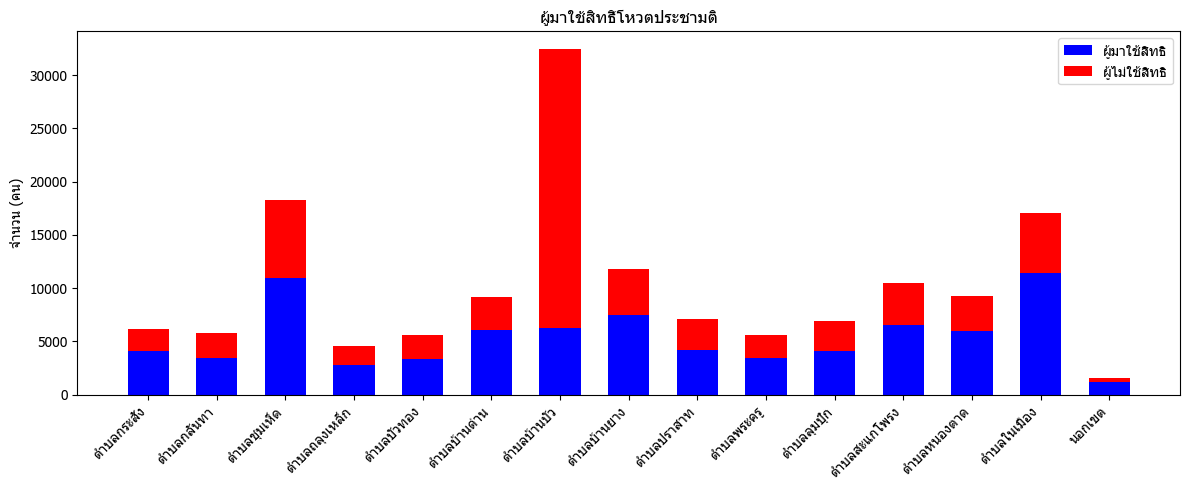

In [32]:
ref = referendum_summary.groupby("ตำบล").agg({
    "ผู้มีสิทธิ": "sum", "ผู้มาใช้สิทธิ": "sum"}).reset_index()

ref["ผู้ไม่ใช้สิทธิ"] = ref["ผู้มีสิทธิ"] - ref["ผู้มาใช้สิทธิ"]
ref["% ใช้สิทธิ์"] = ref["ผู้มาใช้สิทธิ"] / ref["ผู้มีสิทธิ"]

display(ref)

x = np.arange(len(ref))
w = 0.6

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x, ref["ผู้มาใช้สิทธิ"], w, label="ผู้มาใช้สิทธิ", color="blue")
ax.bar(x, ref["ผู้ไม่ใช้สิทธิ"], w, bottom=ref["ผู้มาใช้สิทธิ"], label="ผู้ไม่ใช้สิทธิ", color="red")

ax.set_xticks(x)
ax.set_xticklabels(ref["ตำบล"], rotation=45, ha="right")
ax.set_ylabel("จำนวน (คน)")
ax.set_title("ผู้มาใช้สิทธิ์โหวตประชามติ")
ax.legend()

plt.tight_layout()
plt.show()